# TESS Transit Search Reproduction and Diagnostics

This notebook parses the relevant terminal artifacts, verifies the Python environment, queries MAST for the public QLP product, runs focused tests, and reproduces the Sector 10 pilot. The pilot is a one-target workflow check, not a population completeness or occurrence result.

## 1. Load and Parse Terminal Session Artifacts

Paste selected terminal output into the cell below. The parser splits on shell prompts and records command, stdout, stderr, and inferred status so path mistakes and test failures remain distinguishable.

In [1]:
from tdpy.verbosity import print as narrate
import re
from pathlib import Path
import pandas as pd

terminal_text = r'''$ python -m pytest tests/test_tess_transit_survey.py -q
no tests ran in 0.00s
ERROR: file or directory not found: tests/test_tess_transit_survey.py
$ python -m pytest tests/test_tess_transit_survey.py -q
NameError: name 'pytest' is not defined
1 failed, 3 passed
$ python -m pytest tests/test_tess_transit_survey.py -q
7 passed
$ python -c 'inspect downloaded QLP FITS'
rows 950 baseline_days 24.916358229622574 median_error 0.0007259935871703054'''


def parse_terminal_blocks(text):
    blocks = re.split(r"(?m)^\$ ", text.strip())
    records = []
    for block in blocks:
        if not block.strip():
            continue
        lines = block.splitlines()
        command, output = lines[0], lines[1:]
        error_lines = [line for line in output if re.search(r"ERROR:|Traceback|NameError|failed|file or directory not found", line, re.I)]
        stdout_lines = [line for line in output if line not in error_lines]
        status = 1 if error_lines else (0 if any(re.search(r"\bpassed\b|rows 950", line) for line in output) else None)
        records.append({"command": command, "stdout": "\n".join(stdout_lines),
                        "stderr": "\n".join(error_lines), "status": status})
    return pd.DataFrame(records)


terminal_records = parse_terminal_blocks(terminal_text)
terminal_records

,command,stdout,stderr,status
0,python -m pytest tests/test_tess_transit_surve...,no tests ran in 0.00s,ERROR: file or directory not found: tests/test...,1
1,python -m pytest tests/test_tess_transit_surve...,,NameError: name 'pytest' is not defined\n1 fai...,1
2,python -m pytest tests/test_tess_transit_surve...,7 passed,,0
3,python -c 'inspect downloaded QLP FITS',rows 950 baseline_days 24.916358229622574 medi...,,0


## 2. Validate Python Environment and Dependency Availability

Check required and optional packages before querying MAST. Missing dependencies are shown with concise installation hints.

In [2]:
import importlib.util
import os
import sys

workspace_candidates = [Path.cwd(), *Path.cwd().parents]
MILETOS_REPO = next(
    path for path in workspace_candidates
    if (path / "miletos" / "tess_transit_survey.py").is_file()
    and (path / "pyproject.toml").is_file()
)
PERGAMON_REPO = MILETOS_REPO.parent / "pergamon"
sys.path.insert(0, str(MILETOS_REPO))
os.environ.setdefault("MILETOS_PATH", str(MILETOS_REPO))

required_packages = ["numpy", "pandas", "astropy", "astroquery", "miletos"]
optional_packages = ["lightkurve", "pergamon", "pcat"]
environment_checks = pd.DataFrame([
    {"package": name, "available": importlib.util.find_spec(name) is not None,
     "kind": "required" if name in required_packages else "optional"}
    for name in required_packages + optional_packages
])
install_hints = {
    row.package: (f"Install with `python -m pip install {row.package}`" if not row.available else "available")
    for row in environment_checks.itertuples()
}
display(environment_checks)
install_hints

,package,available,kind
0,numpy,True,required
1,pandas,True,required
2,astropy,True,required
3,astroquery,True,required
4,miletos,True,required
5,lightkurve,False,optional
6,pergamon,True,optional
7,pcat,True,optional


{'numpy': 'available',
 'pandas': 'available',
 'astropy': 'available',
 'astroquery': 'available',
 'miletos': 'available',
 'lightkurve': 'Install with `python -m pip install lightkurve`',
 'pergamon': 'available',
 'pcat': 'available'}

## 3. Query MAST for QLP Observation and Product Metadata

Use the documented exact-TIC query and sector filter. This metadata-only step confirms the QLP observations and FITS product before download.

In [3]:
from astroquery.mast import Observations

TIC_ID = 260128333
SECTOR = 10
observations = Observations.query_criteria(
    provenance_name="QLP", target_name=str(TIC_ID), sequence_number=SECTOR
)
products = Observations.get_product_list(observations) if len(observations) else None
observation_table = observations.to_pandas() if len(observations) else pd.DataFrame()
product_table = products.to_pandas() if products is not None and len(products) else pd.DataFrame()
product_names = product_table.get("productFilename", pd.Series(dtype=str))
qlp_fits_products = product_table[product_names.astype(str).str.endswith("_llc.fits")]
print(f"MAST QLP observations: {len(observation_table)}")
print(f"QLP FITS products: {len(qlp_fits_products)}")
display(observation_table.head())
display(qlp_fits_products[["productFilename"]].head())

MAST QLP observations: 1
QLP FITS products: 1


,intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,...,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max
0,science,HLSP,QLP,Photometer,TESS,TESS,Optical,260128333,NaN,hlsp_qlp_tess_ffi_s0010-0000000260128333_tess_...,...,CIRCLE ICRS 92.13319962 -59.54113338 0.00111111,NaN,mast:HLSP/qlp/s0010/0000/0002/6012/8333/hlsp_q...,PUBLIC,False,NaN,51233934,95175536,600.0,1000.0


,productFilename
0,hlsp_qlp_tess_ffi_s0010-0000000260128333_tess_...


## 4. Run Pytest and Capture Test Diagnostics

Run focused tests in both repositories. Keep complete command output in the notebook state and expose concise failure lines for quick diagnosis.

In [4]:
import subprocess

pytest_jobs = [
    ("Miletos transit survey", MILETOS_REPO, ["tests/test_tess_transit_survey.py"]),
    ("Pergamon occurrence", PERGAMON_REPO, ["tests/test_popl.py"]),
]
test_runs = []
for label, repository, test_paths in pytest_jobs:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", "-q", *test_paths],
        cwd=repository, capture_output=True, text=True, timeout=180,
    )
    output = completed.stdout + completed.stderr
    summary = next((line for line in output.splitlines() if re.search(r"\d+ passed|failed|error", line)), "No pytest summary line")
    failure_lines = [line for line in output.splitlines() if re.search(r"FAILED|ERROR|NameError|not found", line)]
    test_runs.append({"repository": label, "path": str(repository), "returncode": completed.returncode,
                      "summary": summary, "failure_diagnostics": "\n".join(failure_lines), "output": output})
test_summary = pd.DataFrame([{key: run[key] for key in
                              ("repository", "path", "returncode", "summary", "failure_diagnostics")}
                             for run in test_runs])
display(test_summary)

,repository,path,returncode,summary,failure_diagnostics
0,Miletos transit survey,miletos,0,"[33m[32m7 passed[0m, [33m[1m1 warning[0m...",
1,Pergamon occurrence,pergamon,0,"[33m[32m9 passed[0m, [33m[1m1 warning[0m...",


## 5. Reproduce and Fix the `pytest` NameError Pattern

A test that calls `pytest.approx` without importing pytest fails at runtime. Reproduce that failure in a temporary directory, add the missing import, and rerun without changing repository tests.

In [5]:
import tempfile

minimal_test = "def test_value():\n    assert pytest.approx(1.0) == 1.0\n"
with tempfile.TemporaryDirectory() as temporary_directory:
    minimal_test_path = Path(temporary_directory) / "test_missing_pytest_import.py"
    narrate(f"Writing to {minimal_test_path}...")
    minimal_test_path.write_text(minimal_test)
    failing_run = subprocess.run(
        [sys.executable, "-m", "pytest", "-q", str(minimal_test_path)],
        capture_output=True, text=True,
    )
    failure_text = failing_run.stdout + failing_run.stderr
    print(f"Expected failing return code: {failing_run.returncode}")
    print("NameError reproduced:", "NameError: name 'pytest' is not defined" in failure_text)

    fixed_test = "import pytest\n\ndef test_value():\n    assert pytest.approx(1.0) == 1.0\n"
    narrate(f"Writing to {minimal_test_path}...")
    minimal_test_path.write_text(fixed_test)
    fixed_run = subprocess.run(
        [sys.executable, "-m", "pytest", "-q", str(minimal_test_path)],
        capture_output=True, text=True,
    )
    print(f"Fixed return code: {fixed_run.returncode}")
    print(fixed_run.stdout.strip())

Writing to [local path removed]2qy1ffhd2t9bwpmp258d60k40000gq/T/tmpy3z58d08/test_missing_pytest_import.py...


Expected failing return code: 1
NameError reproduced: True
Writing to [local path removed]2qy1ffhd2t9bwpmp258d60k40000gq/T/tmpy3z58d08/test_missing_pytest_import.py...


Fixed return code: 0
.                                                                        [100%]
1 passed in 0.00s


## 6. Download QLP FITS Files and Read Light Curves

Download the matching QLP FITS product through the Miletos API, verify each local file, apply the quality mask and normalization, and summarize the observed cadence baseline and uncertainty.

In [6]:
from miletos.paths import get_data_path
from miletos.tess_transit_survey import download_qlp_light_curves, read_qlp_light_curve

QLP_CACHE = get_data_path() / "tess_transit_survey"
qlp_paths = download_qlp_light_curves([TIC_ID], [SECTOR], QLP_CACHE)
assert qlp_paths and all(path.is_file() for path in qlp_paths)
matching_path = next(path for path in qlp_paths if path.name.endswith("_llc.fits"))
real_curve = read_qlp_light_curve(matching_path)
light_curve_metrics = pd.DataFrame([{
    "tic_id": TIC_ID,
    "sector": SECTOR,
    "rows": len(real_curve),
    "baseline_days": real_curve["time_btjd"].max() - real_curve["time_btjd"].min(),
    "median_flux_uncertainty": real_curve["flux_error"].median(),
    "path": str(matching_path),
}])
display(light_curve_metrics)

INFO: Found cached file miletos/data/tess_transit_survey/mastDownload/HLSP/hlsp_qlp_tess_ffi_s0010-0000000260128333_tess_v01_llc/hlsp_qlp_tess_ffi_s0010-0000000260128333_tess_v01_llc.fits with expected size 77760. [astroquery.query]


,tic_id,sector,rows,baseline_days,median_flux_uncertainty,path
0,260128333,10,950,24.916358,0.000726,miletos/data...


## 7. Run Transit Search on Real and Synthetic Curves

Inject a known periodic box into a deterministic simulated light curve to verify period recovery, then apply the same Miletos search and vetter to the downloaded QLP data. The observed signal is a review item because the inverted control is stronger.

,case,injected_period_days,period_days,depth,depth_snr,inverted_depth_snr,disposition
0,synthetic injection,3.0,2.997798,0.010020,69.661217,7.168734,review
1,TIC 260128333 Sector 10,NaN,7.354890,0.001428,6.772383,8.336485,review


Reading from miletos/examples/tess_transit_search/visuals/toi1338_sector10_candidate.png...


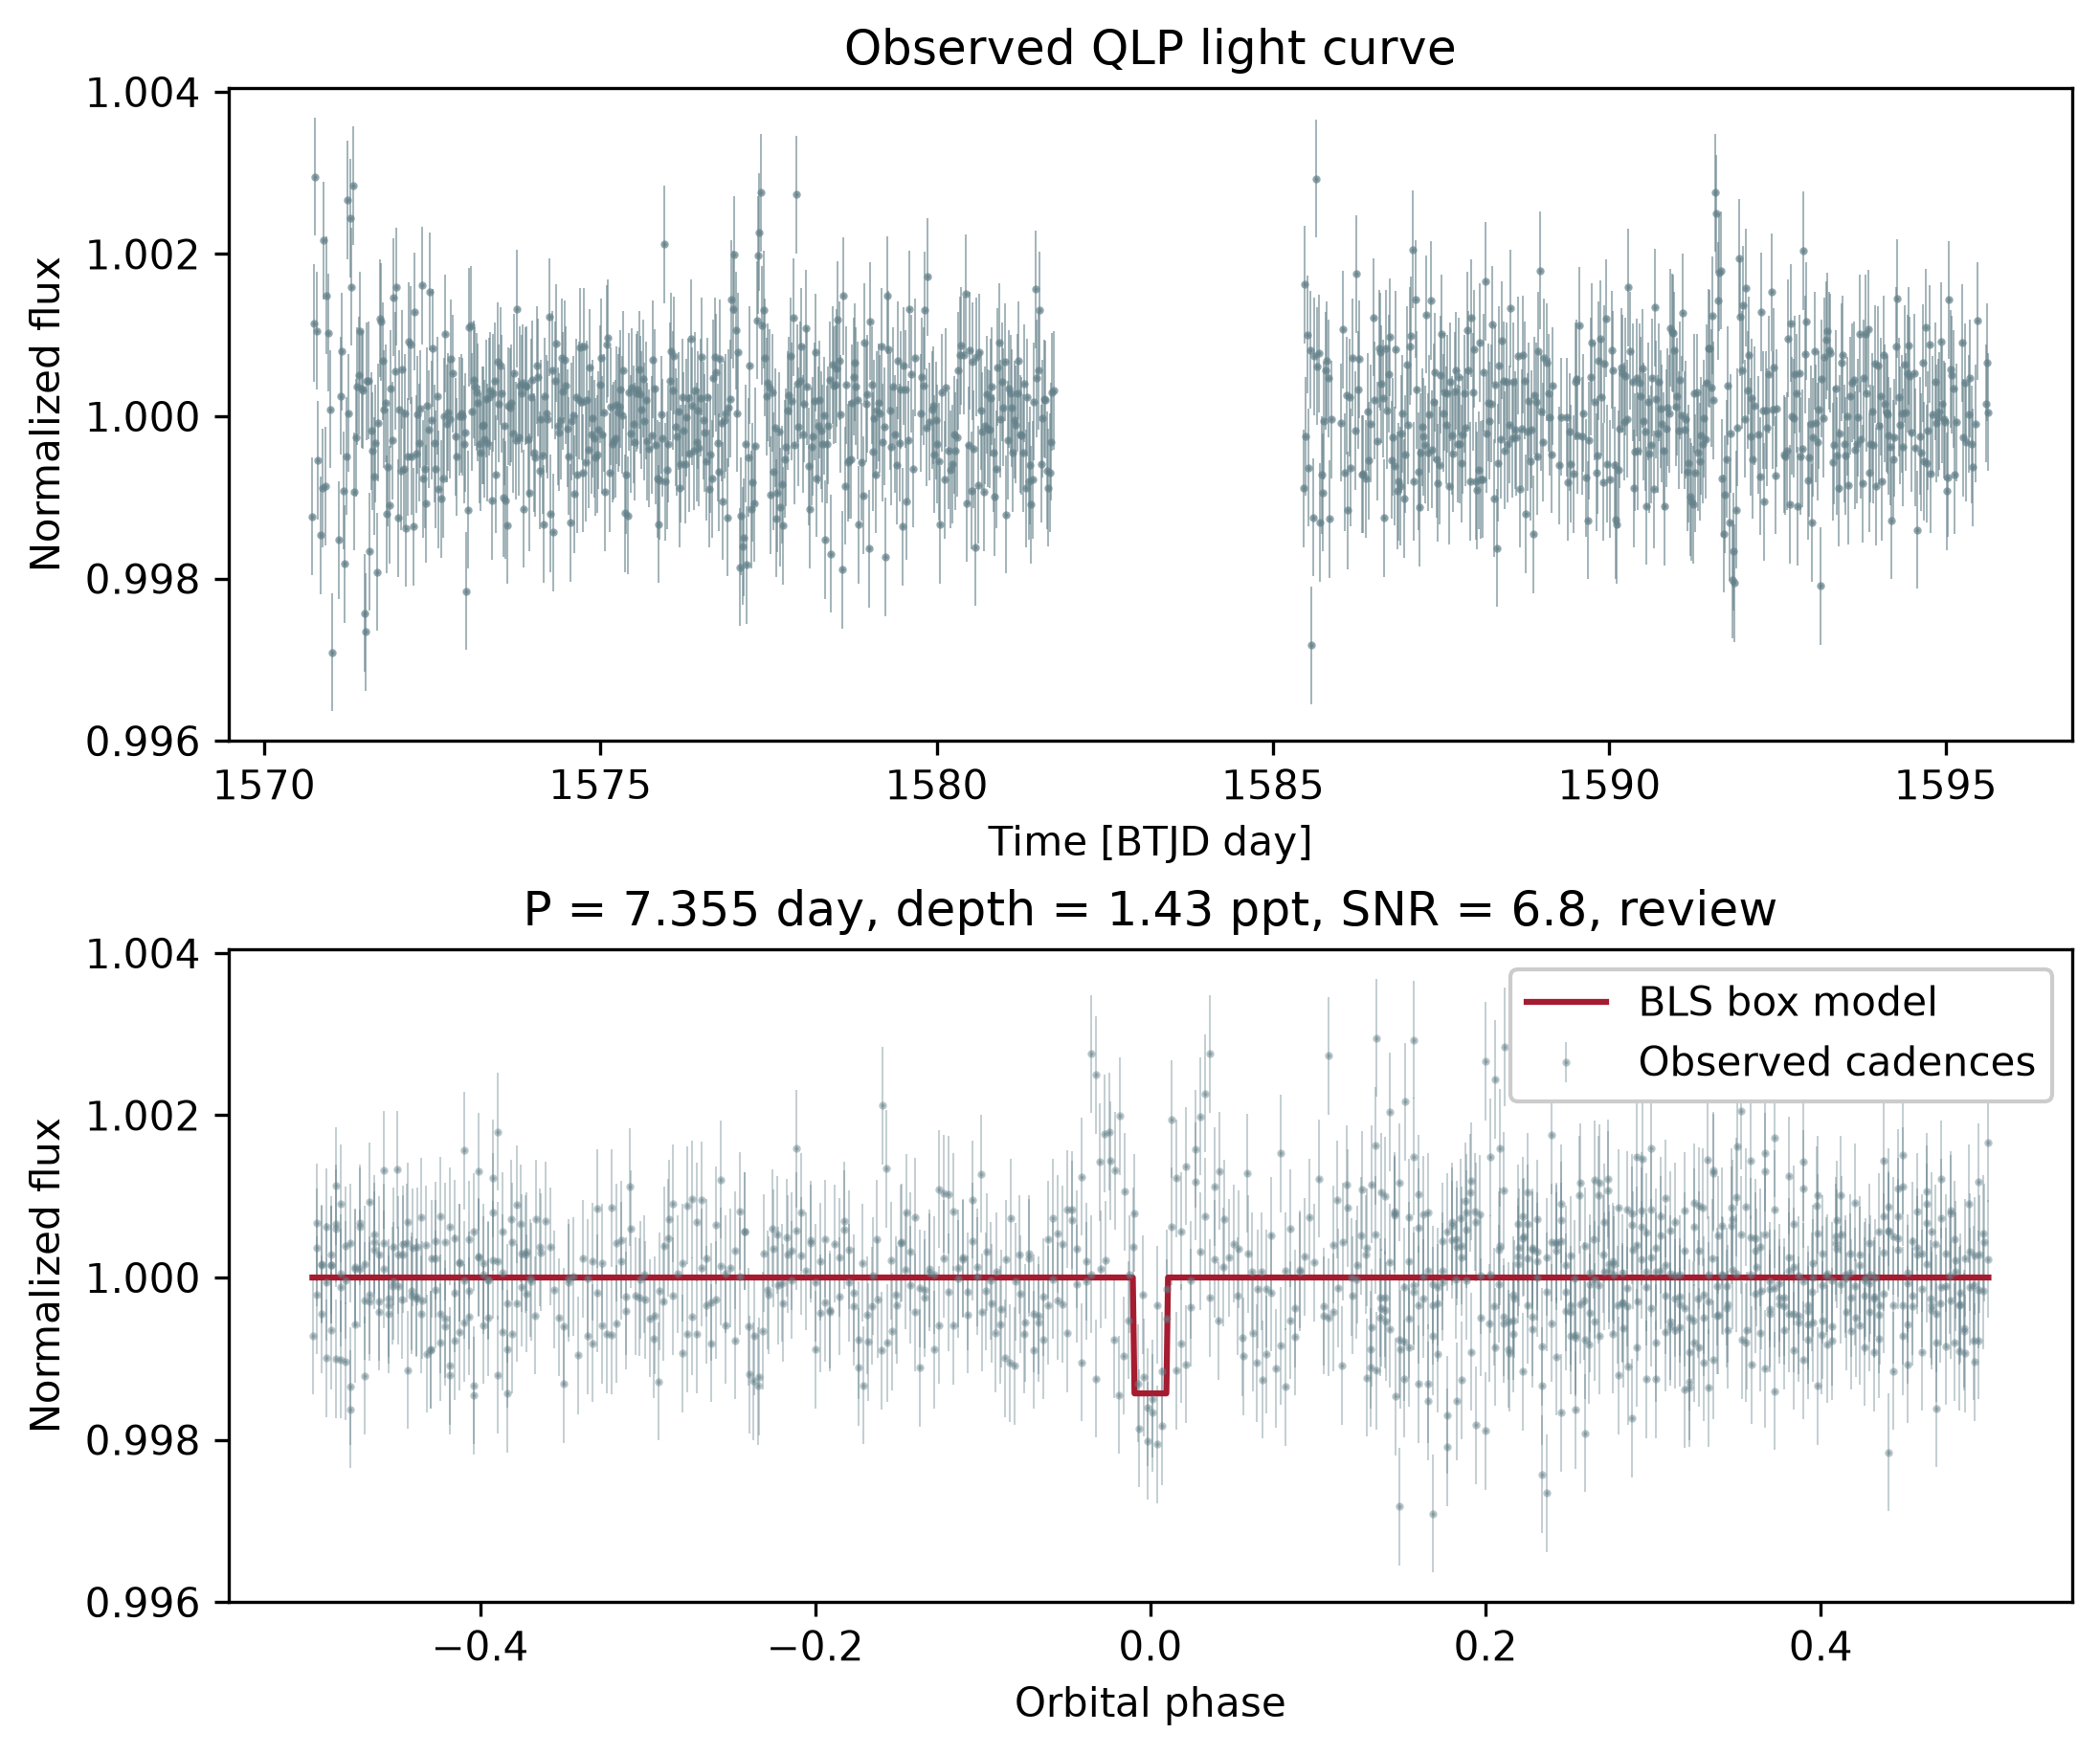

Reading from miletos/examples/tess_transit_search/visuals/tess_transit_completeness.png...


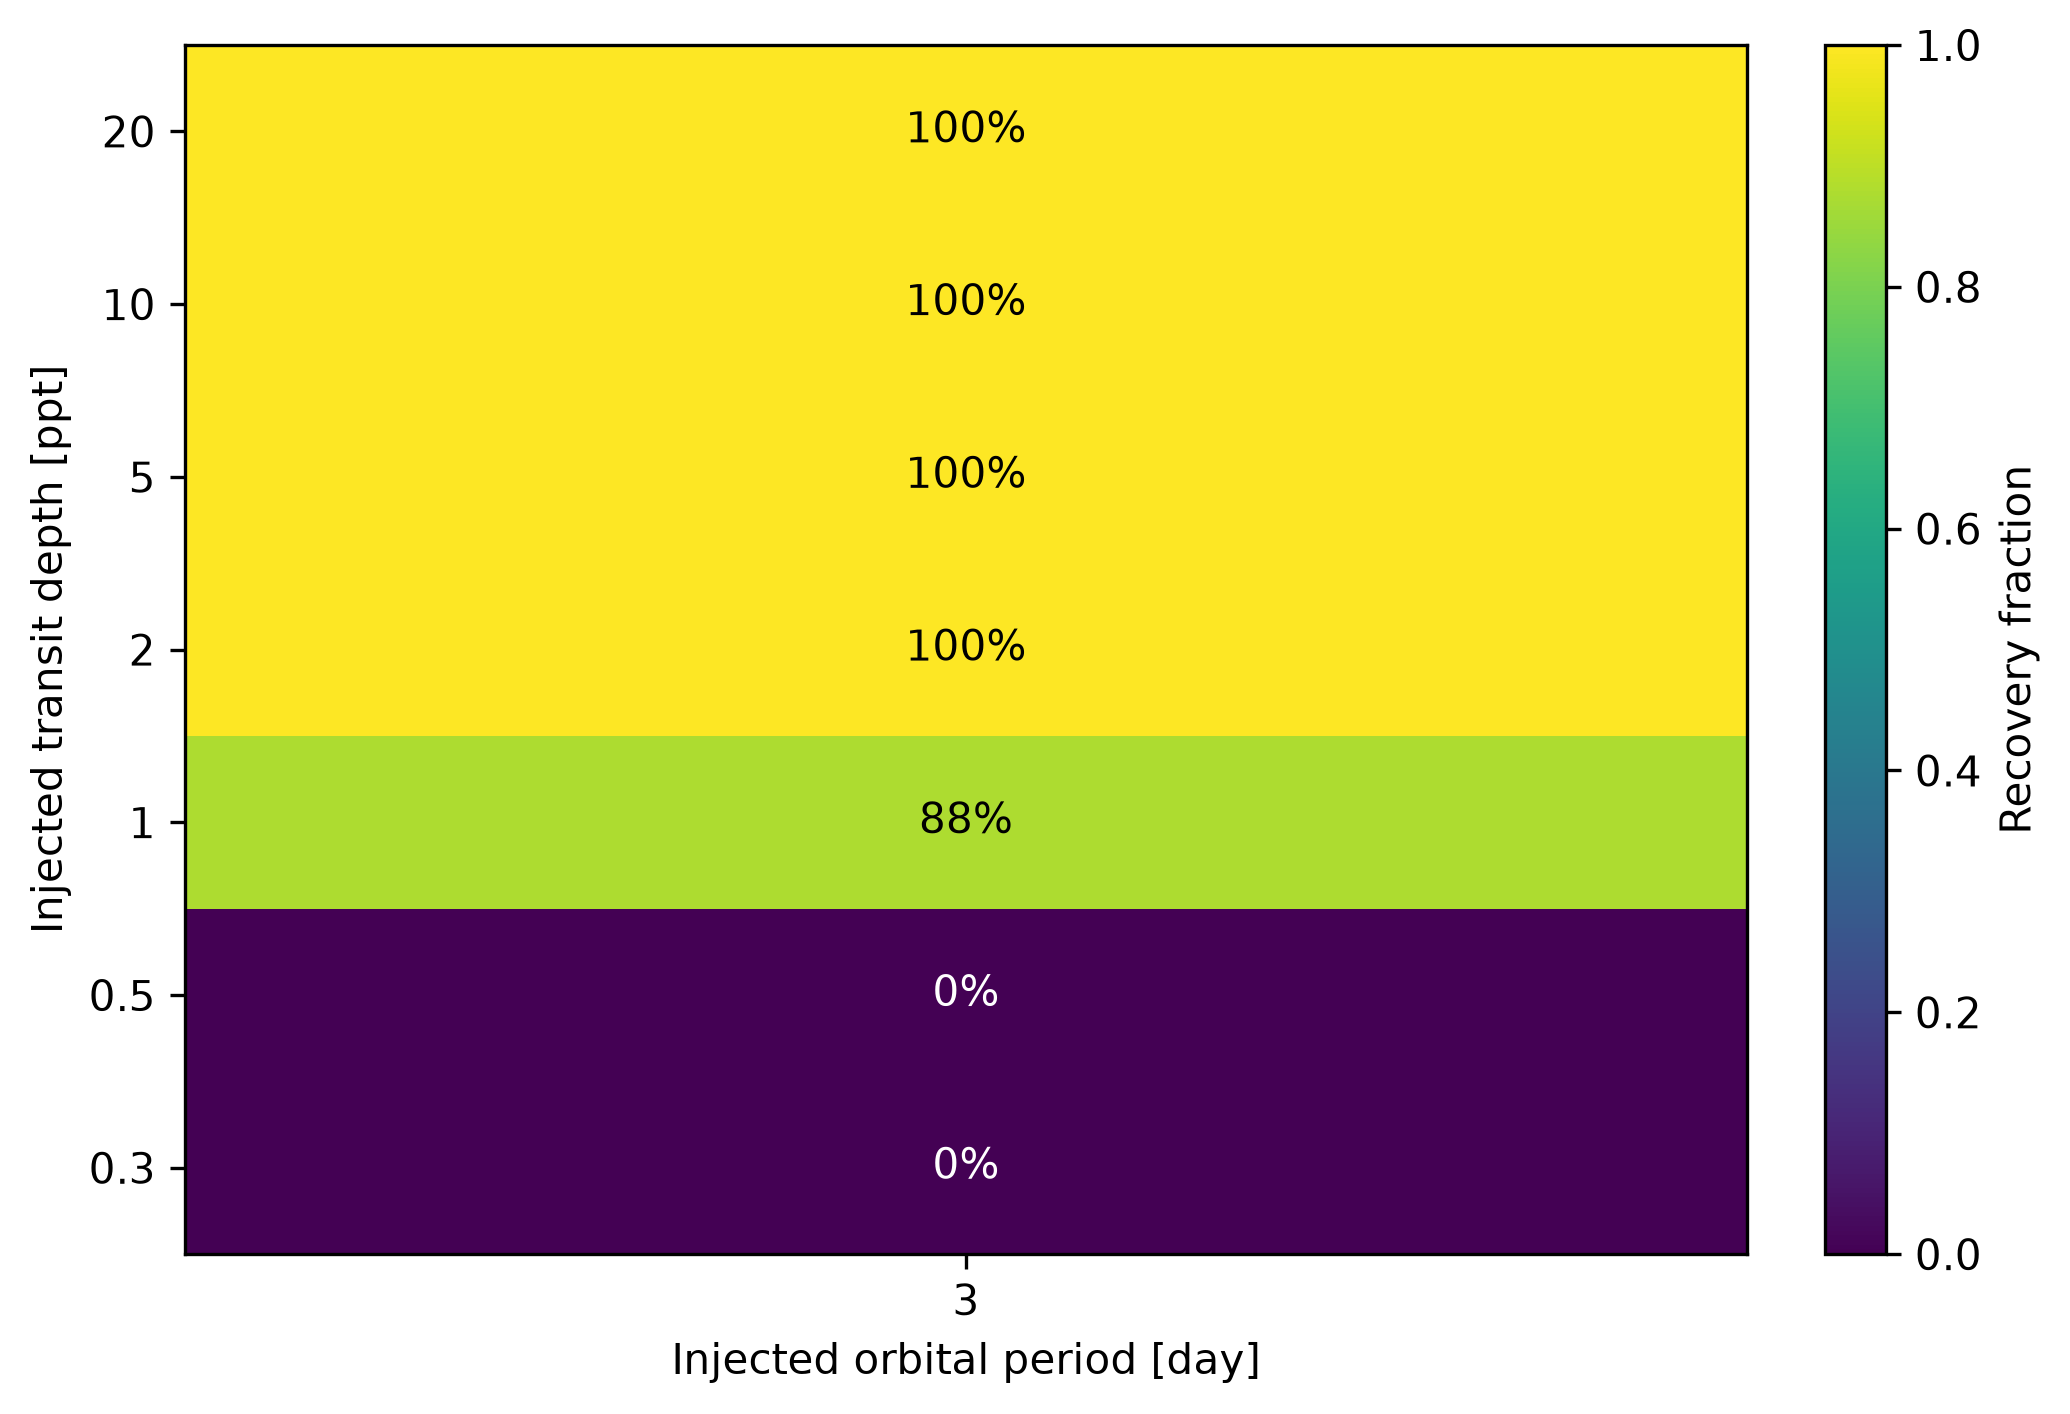

Reading from miletos/examples/tess_transit_search/visuals/tess_transit_search_yield.png...


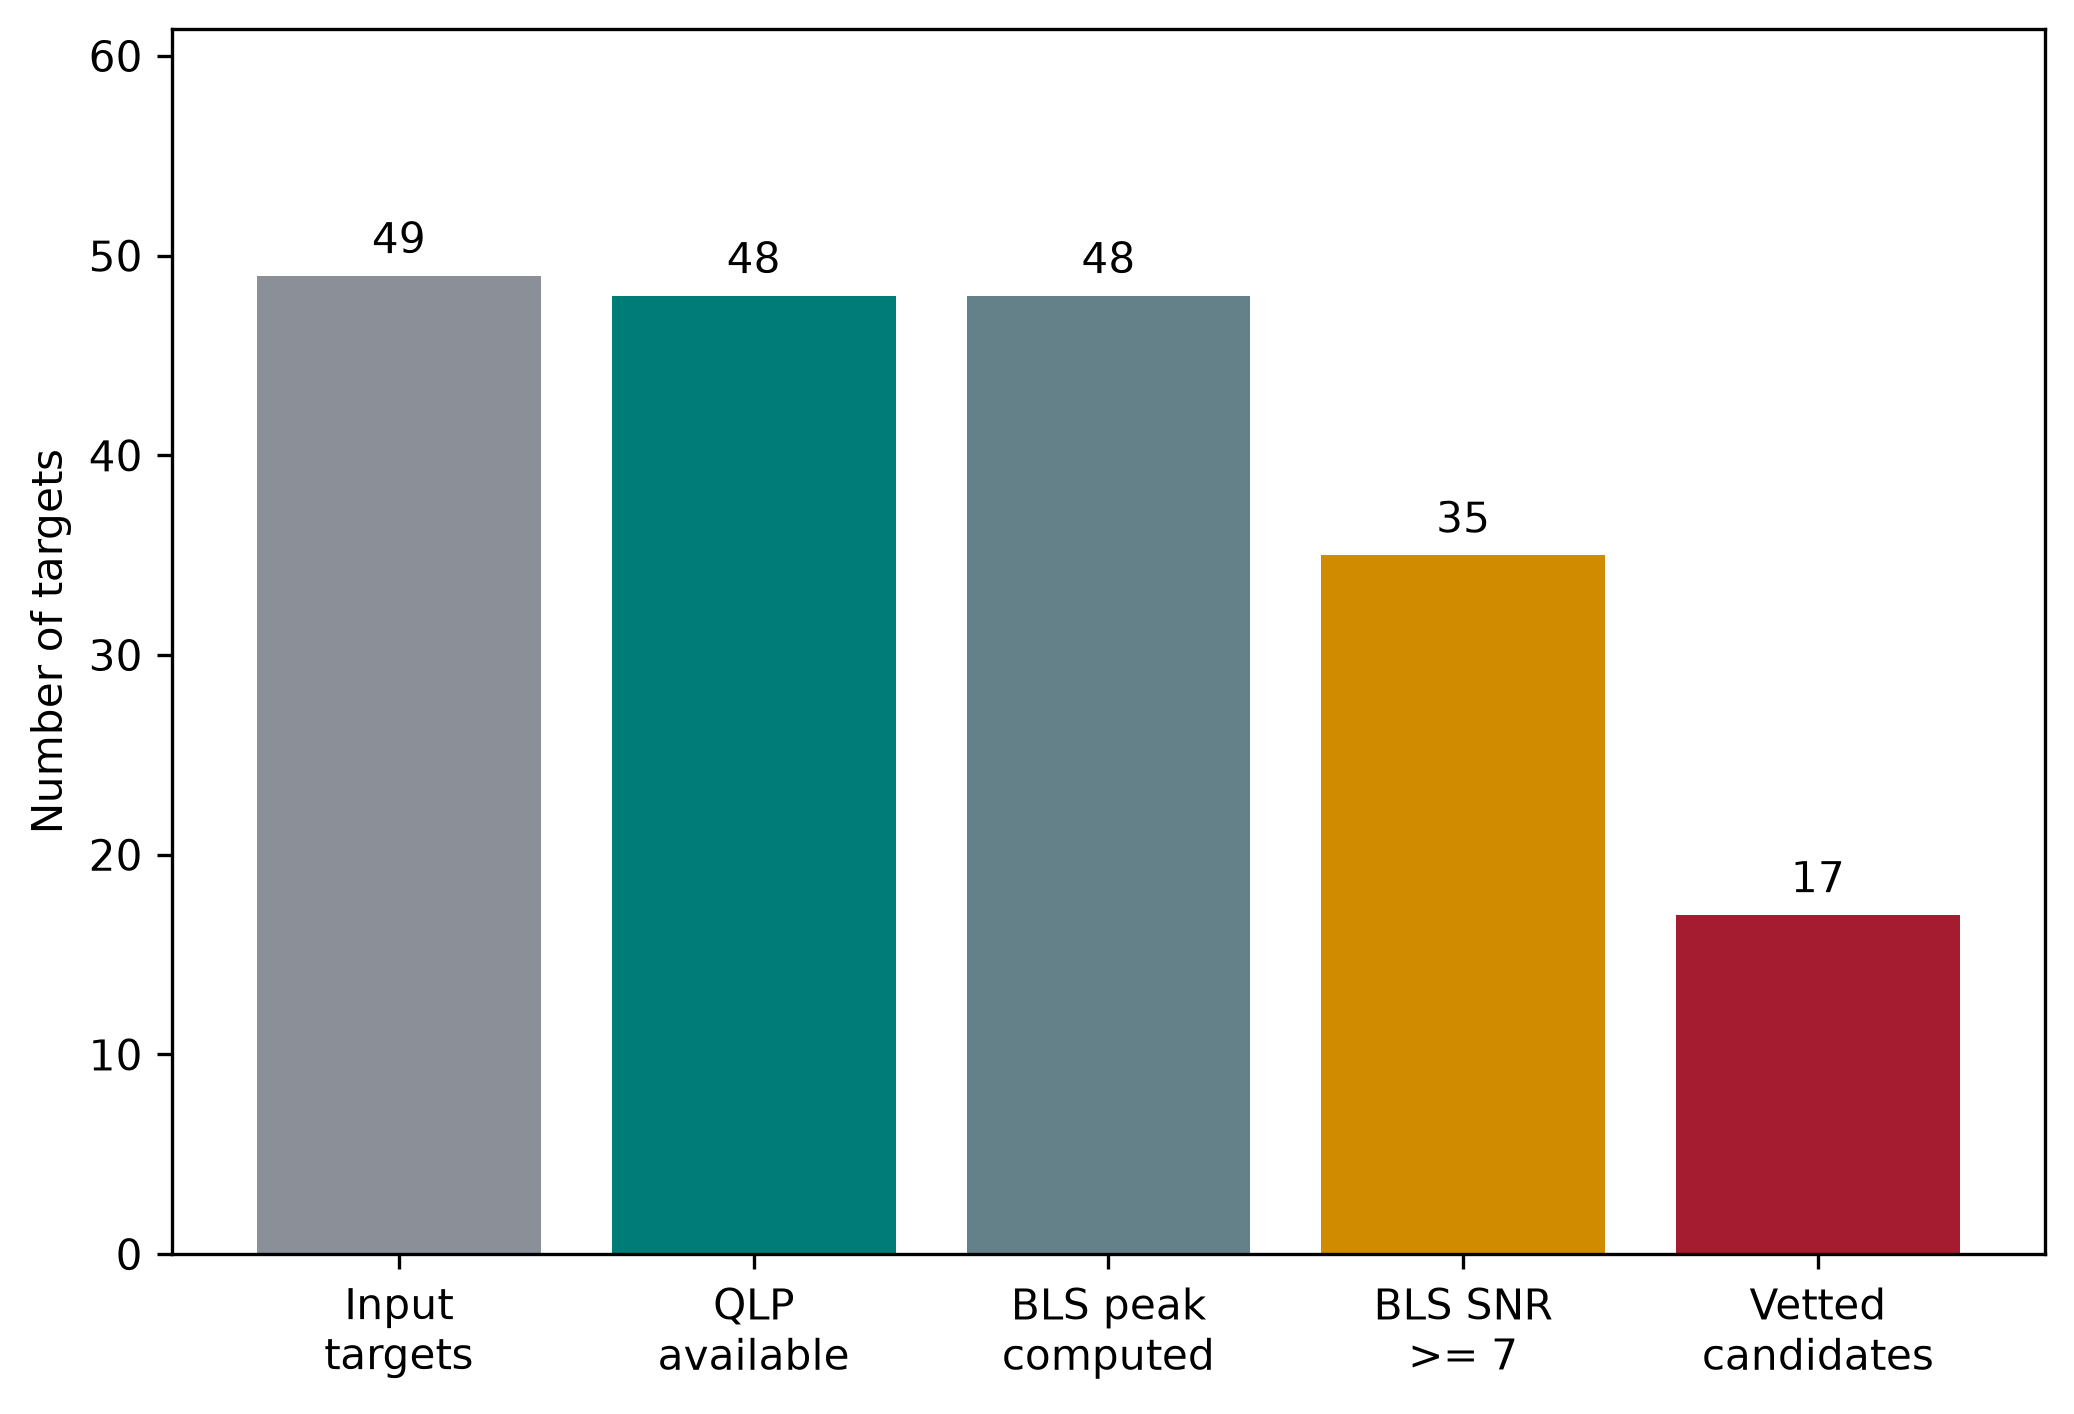

Reading from miletos/examples/tess_transit_search/visuals/tess_transit_false_alarm_control.png...


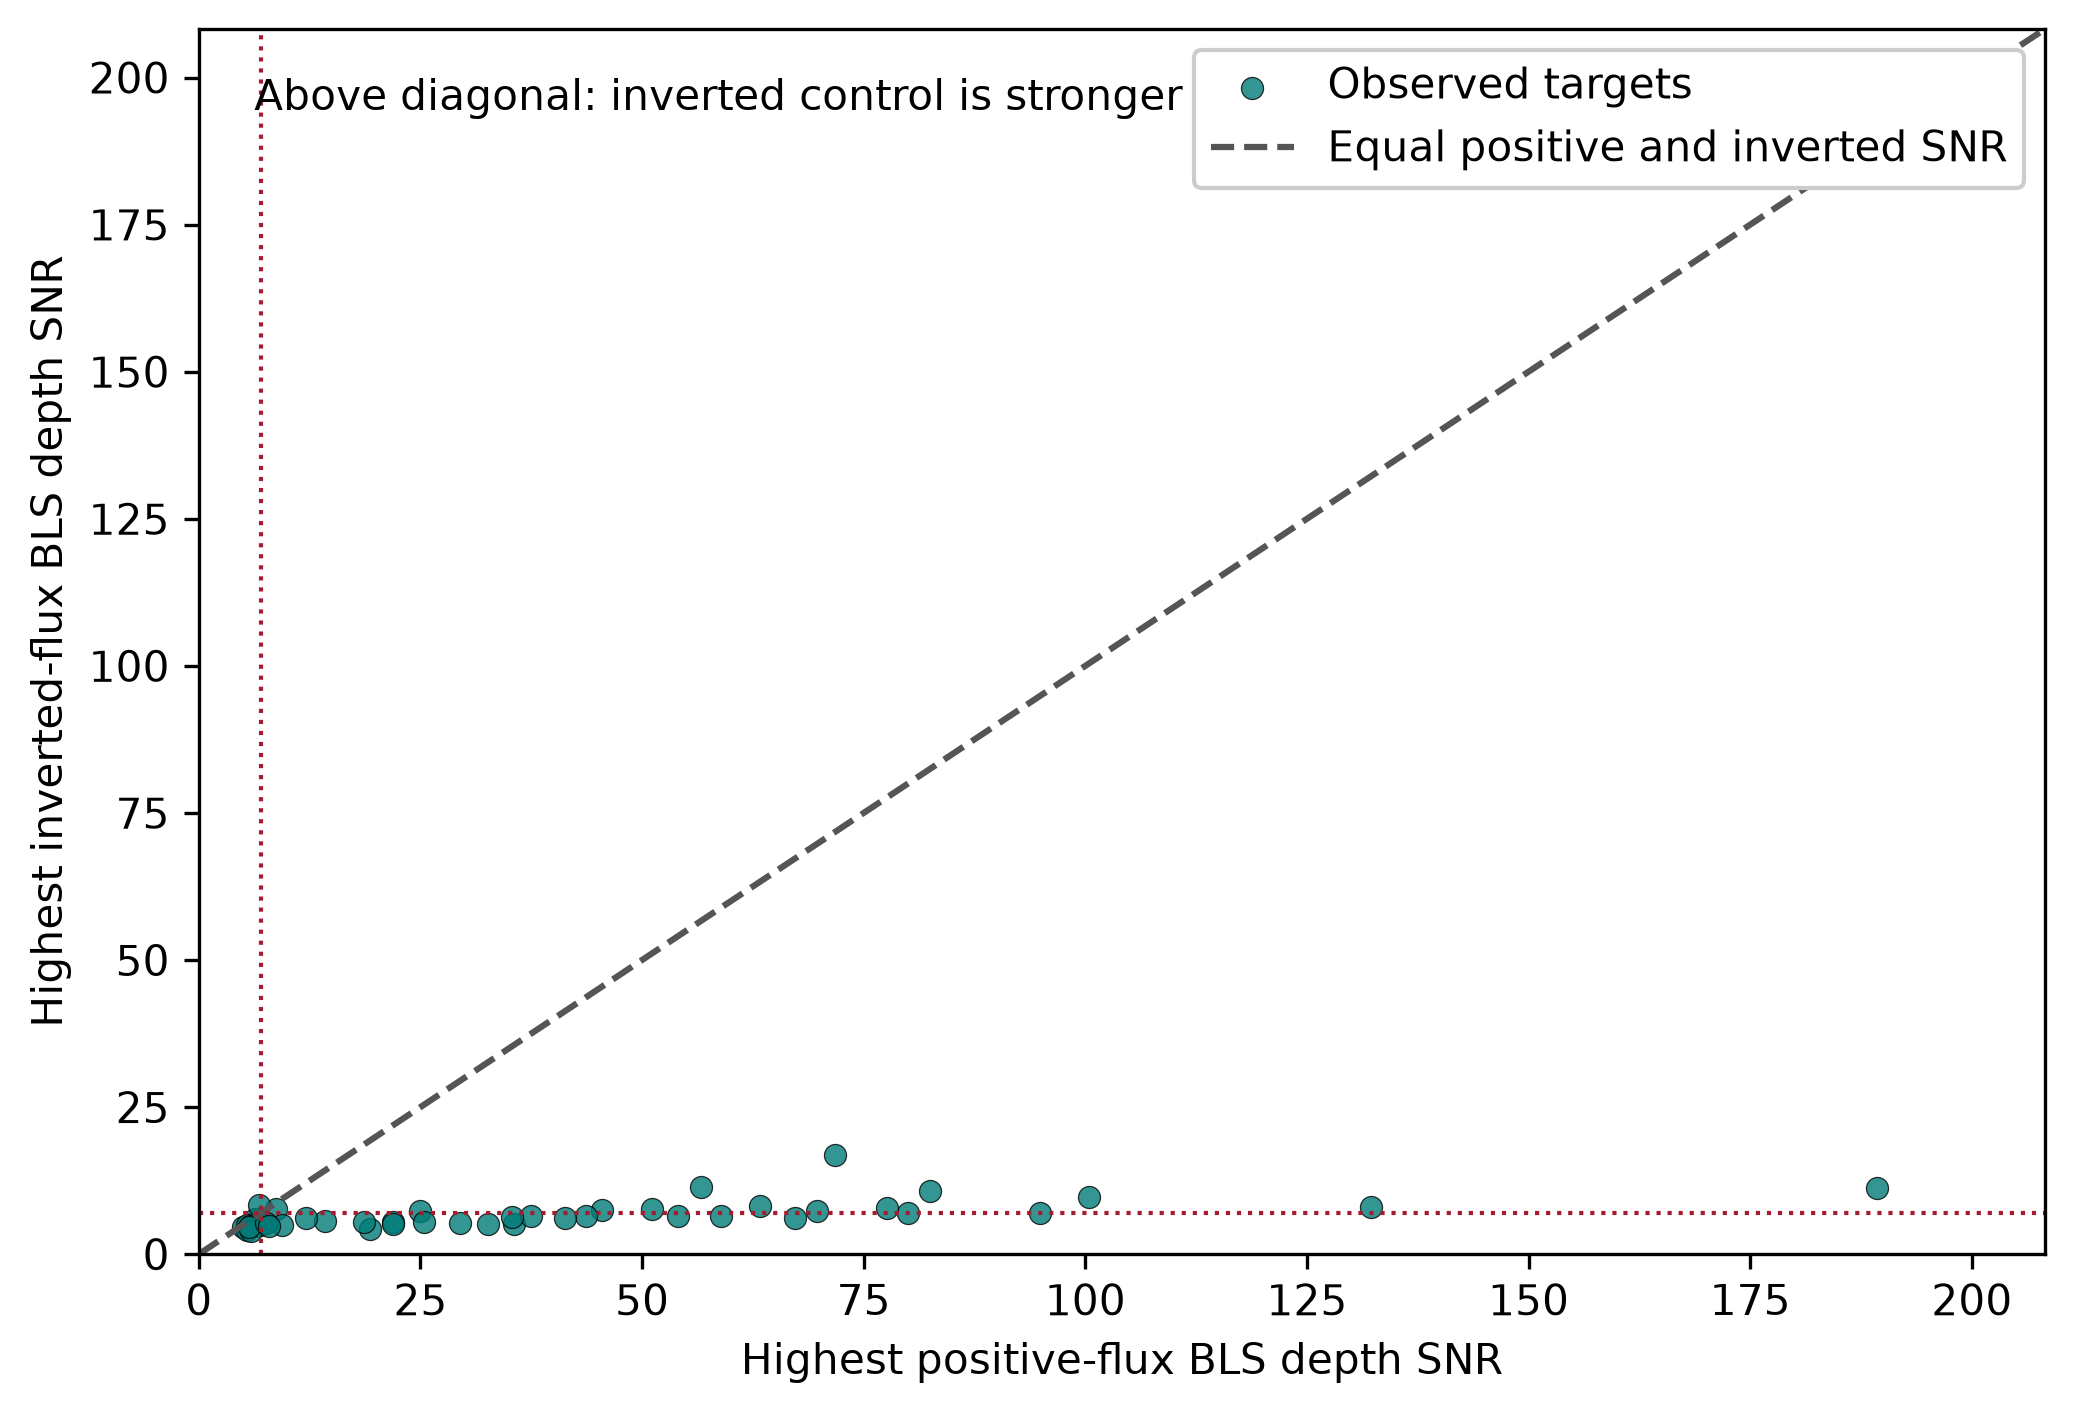

In [7]:
import numpy as np
from miletos.tess_transit_survey import search_tess_target

synthetic_time = np.arange(0.0, 30.0, 0.02)  # [day]
injected_period = 3.0  # [day]
injected_epoch = 0.4  # [day]
injected_duration = 0.10  # [day]
time_phase = (synthetic_time - injected_epoch + injected_period / 2) % injected_period - injected_period / 2
synthetic_flux = np.ones_like(synthetic_time)
synthetic_flux[np.abs(time_phase) < injected_duration / 2] -= 0.01
synthetic_error = np.full(synthetic_time.size, 0.001)
synthetic_flux += np.random.default_rng(9).normal(0.0, synthetic_error)
synthetic_curve = pd.DataFrame({"time_btjd": synthetic_time, "flux": synthetic_flux,
                                "flux_error": synthetic_error})
synthetic_search = search_tess_target(
    synthetic_curve, minimum_period_days=2.5, maximum_period_days=3.5,  # [day]
    duration_days=(0.10, 0.12, 0.14),  # [day]
)
real_maximum_period = min(8.0, float(light_curve_metrics.loc[0, "baseline_days"]) / 3.0)  # [day]
real_search = search_tess_target(
    real_curve, minimum_period_days=0.5, maximum_period_days=real_maximum_period,  # [day]
)
search_comparison = pd.DataFrame([
    {"case": "synthetic injection", "injected_period_days": injected_period,
     **{key: synthetic_search[key] for key in
        ("period_days", "depth", "depth_snr", "inverted_depth_snr", "disposition")}},
    {"case": "TIC 260128333 Sector 10", "injected_period_days": np.nan,
     **{key: real_search[key] for key in
        ("period_days", "depth", "depth_snr", "inverted_depth_snr", "disposition")}},
])
display(search_comparison)

from IPython.display import Image, display
PILOT_VISUALS = MILETOS_REPO / "examples" / "tess_transit_search" / "visuals"
for figure_name in ("toi1338_sector10_candidate.png", "tess_transit_completeness.png",
                    "tess_transit_search_yield.png", "tess_transit_false_alarm_control.png"):
    figure_path = PILOT_VISUALS / figure_name
    if figure_path.is_file():
        narrate(f"Reading from {figure_path}...")
        display(Image(filename=str(figure_path)))

## 8. Persist Results and Emit a Reproducibility Snapshot

Save compact tables and JSON metadata in the example visuals directory. The record includes the Python/runtime versions, environment availability, MAST product names, test return codes, and both observed and injected-search summaries.

In [8]:
from datetime import datetime, timezone
import importlib.metadata
import json

EXAMPLE_VISUALS = MILETOS_REPO / "examples" / "tess_transit_search" / "visuals"
EXAMPLE_VISUALS.mkdir(parents=True, exist_ok=True)
package_names = ["numpy", "pandas", "astropy", "astroquery", "miletos", "pergamon", "lightkurve"]
package_versions = {}
for package_name in package_names:
    try:
        package_versions[package_name] = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package_name] = None

snapshot = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "miletos_repository": str(MILETOS_REPO),
    "tic_id": TIC_ID,
    "sector": SECTOR,
    "package_versions": package_versions,
    "environment_checks": environment_checks.to_dict(orient="records"),
    "mast_observations": observation_table.to_dict(orient="records"),
    "mast_qlp_fits_products": qlp_fits_products[["productFilename"]].to_dict(orient="records"),
    "test_summary": test_summary.to_dict(orient="records"),
    "synthetic_search": synthetic_search,
    "real_search": real_search,
}
output_paths = {
    "snapshot": EXAMPLE_VISUALS / "tess_transit_reproducibility.json",
    "environment": EXAMPLE_VISUALS / "tess_transit_environment.csv",
    "tests": EXAMPLE_VISUALS / "tess_transit_test_summary.csv",
    "searches": EXAMPLE_VISUALS / "tess_transit_search_comparison.csv",
    "observations": EXAMPLE_VISUALS / "tess_qlp_observation_metadata.csv",
}
narrate(f"Writing to {output_paths['snapshot']}...")
output_paths["snapshot"].write_text(json.dumps(snapshot, indent=2, default=str) + "\n")
narrate(f"Writing to {output_paths['environment']}...")
environment_checks.to_csv(output_paths["environment"], index=False)
narrate(f"Writing to {output_paths['tests']}...")
test_summary.to_csv(output_paths["tests"], index=False)
narrate(f"Writing to {output_paths['searches']}...")
search_comparison.to_csv(output_paths["searches"], index=False)
narrate(f"Writing to {output_paths['observations']}...")
observation_table.to_csv(output_paths["observations"], index=False)
output_paths

Writing to miletos/examples/tess_transit_search/visuals/tess_transit_reproducibility.json...
Writing to miletos/examples/tess_transit_search/visuals/tess_transit_environment.csv...
Writing to miletos/examples/tess_transit_search/visuals/tess_transit_test_summary.csv...
Writing to miletos/examples/tess_transit_search/visuals/tess_transit_search_comparison.csv...
Writing to miletos/examples/tess_transit_search/visuals/tess_qlp_observation_metadata.csv...


{'snapshot': PosixPath('miletos/examples/tess_transit_search/visuals/tess_transit_reproducibility.json'),
 'environment': PosixPath('miletos/examples/tess_transit_search/visuals/tess_transit_environment.csv'),
 'tests': PosixPath('miletos/examples/tess_transit_search/visuals/tess_transit_test_summary.csv'),
 'searches': PosixPath('miletos/examples/tess_transit_search/visuals/tess_transit_search_comparison.csv'),
 'observations': PosixPath('miletos/examples/tess_transit_search/visuals/tess_qlp_observation_metadata.csv')}